In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
train_data=pd.read_excel(r'Data\Data_Train.xlsx')

In [4]:
test_data=pd.read_excel(r"Data\Test_set.xlsx")

In [5]:
pd.set_option('Display.max_columns',None)

In [6]:
train_data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [7]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 918.2 KB


In [8]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          2671 non-null   str  
 1   Date_of_Journey  2671 non-null   str  
 2   Source           2671 non-null   str  
 3   Destination      2671 non-null   str  
 4   Route            2671 non-null   str  
 5   Dep_Time         2671 non-null   str  
 6   Arrival_Time     2671 non-null   str  
 7   Duration         2671 non-null   str  
 8   Total_Stops      2671 non-null   str  
 9   Additional_Info  2671 non-null   str  
dtypes: str(10)
memory usage: 208.8 KB


In [9]:
train_data.duplicated().sum()

np.int64(220)

In [10]:
test_data.duplicated().sum()

np.int64(26)

### both the trains and test data have duplicated  records in them but it is not possible in this case so do not remove it

## Missing Values

In [11]:
train_data.isnull().sum()# only 1 missing value in Route and Total_stops in train data

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [12]:
test_data.isnull().sum()## no null values

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
dtype: int64

### Removing the null values from training data

In [13]:
train_data.dropna(inplace=True)

In [14]:
print(train_data.isnull().sum())
print("*"*25)
print(test_data.isnull().sum())
# train and test data have 0 missing value

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64
*************************
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
dtype: int64


In [15]:
print(train_data.shape)

(10682, 11)


### EDA and Data Cleaning

# 1. Data of journey

## Not extracting the year since the data is from 2019 only

In [16]:
print(train_data.columns)

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='str')


In [17]:
## Convert Date_of_Journey to dataset
train_data['Date_of_Journey']=pd.to_datetime(train_data['Date_of_Journey'], format='%d/%m/%Y')
test_data['Date_of_Journey']=pd.to_datetime(test_data['Date_of_Journey'], format= '%d/%m/%Y')

# Extract day and month from date_of_journey
train_data['Journey_Day']= train_data['Date_of_Journey'].dt.day
train_data['Journey_Month']= train_data['Date_of_Journey'].dt.month

test_data['Journey_Day']=test_data['Date_of_Journey'].dt.day
test_data['Journey_Month']=test_data['Date_of_Journey'].dt.month

## Drop date_of_journey as it is now redundant
train_data.drop(['Date_of_Journey'],axis=1, inplace=True)
test_data.drop(['Date_of_Journey'],axis=1,inplace=True)


In [18]:
train_data

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,4
10679,Air India,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,4
10680,Jet Airways,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,27,4
10681,Vistara,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,1,3


# 2. Departure Time and 4. Arrival Time

In [19]:
train_data['Dep_Time']= pd.to_datetime(train_data['Dep_Time'])
train_data['Arrival_Time']= pd.to_datetime(train_data['Arrival_Time'])

test_data['Dep_Time']= pd.to_datetime(test_data['Dep_Time'])
test_data['Arrival_Time']= pd.to_datetime(test_data['Arrival_Time'])

In [20]:
train_data

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month
0,IndiGo,Banglore,New Delhi,BLR → DEL,2026-07-11 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-07-11 05:50:00,2026-07-11 13:15:00,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2026-07-11 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,2026-07-11 18:05:00,2026-07-11 23:30:00,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,2026-07-11 16:50:00,2026-07-11 21:35:00,4h 45m,1 stop,No info,13302,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,2026-07-11 19:55:00,2026-07-11 22:25:00,2h 30m,non-stop,No info,4107,9,4
10679,Air India,Kolkata,Banglore,CCU → BLR,2026-07-11 20:45:00,2026-07-11 23:20:00,2h 35m,non-stop,No info,4145,27,4
10680,Jet Airways,Banglore,Delhi,BLR → DEL,2026-07-11 08:20:00,2026-07-11 11:20:00,3h,non-stop,No info,7229,27,4
10681,Vistara,Banglore,New Delhi,BLR → DEL,2026-07-11 11:30:00,2026-07-11 14:10:00,2h 40m,non-stop,No info,12648,1,3


In [21]:
# Extract hour and minute from Dep_Time and Arrival_Time
train_data['Dep_Hour']= train_data['Dep_Time'].dt.hour
train_data['Dep_Minute']= train_data['Dep_Time'].dt.minute

train_data['Arrival_Hour']= train_data['Arrival_Time'].dt.hour
train_data['Arrival_Minute']= train_data['Arrival_Time'].dt.minute

test_data['Dep_Hour']= test_data['Dep_Time'].dt.hour
test_data['Dep_Minute']= test_data['Dep_Time'].dt.minute

test_data['Arrival_Hour']= test_data['Arrival_Time'].dt.hour
test_data['Arrival_Minute']= test_data['Arrival_Time'].dt.minute

# Drop Dep_time and Arrival_Time as they are now redundant
train_data.drop(['Dep_Time','Arrival_Time'],axis=1, inplace=True)
test_data.drop(['Dep_Time','Arrival_Time'],axis=1,inplace=True)



In [22]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,2h 30m,non-stop,No info,4107,9,4,19,55,22,25
10679,Air India,Kolkata,Banglore,CCU → BLR,2h 35m,non-stop,No info,4145,27,4,20,45,23,20
10680,Jet Airways,Banglore,Delhi,BLR → DEL,3h,non-stop,No info,7229,27,4,8,20,11,20
10681,Vistara,Banglore,New Delhi,BLR → DEL,2h 40m,non-stop,No info,12648,1,3,11,30,14,10


# 4.Duration

In [23]:
### Handling Duration feature
def convert_duration(duration):
    duration=duration.split()
    hours=0
    minutes=0
    for d in duration:
        if 'h' in d:
            hours=int(d[:-1])
        elif 'm' in d:
            minutes = int(d[:-1])
    return hours * 60 + minutes

train_data['Duration']= train_data['Duration'].apply(convert_duration)
test_data['Duration']=test_data['Duration'].apply(convert_duration)

In [24]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,150,non-stop,No info,4107,9,4,19,55,22,25
10679,Air India,Kolkata,Banglore,CCU → BLR,155,non-stop,No info,4145,27,4,20,45,23,20
10680,Jet Airways,Banglore,Delhi,BLR → DEL,180,non-stop,No info,7229,27,4,8,20,11,20
10681,Vistara,Banglore,New Delhi,BLR → DEL,160,non-stop,No info,12648,1,3,11,30,14,10


In [25]:
print(train_data.columns)

Index(['Airline', 'Source', 'Destination', 'Route', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour',
       'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute'],
      dtype='str')


In [26]:
train_data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35


### 5. Creating a new feature "Journey Day" (monday=0,tuesday=1,..........sunday=6)

In [27]:
## Journey Day of week
train_data['Journey_Day_of_Week']=train_data.apply(lambda row: pd.Timestamp(year=2019, month=row['Journey_Month'],
day=row['Journey_Day']).dayofweek,axis=1)

test_data['Journey_Day_of_Week']=test_data.apply(lambda row: pd.Timestamp(year=2019, month=row['Journey_Month'],
day=row['Journey_Day']).dayofweek,axis=1)


### 6. Creating a new feature - whether the day of journey was weekend or not


In [28]:
# Is weekend
train_data['Is_Weekend']=train_data['Journey_Day_of_Week'].apply(lambda x:1 if x>=5 else 0)
test_data['IS_Weekend']= test_data['Journey_Day_of_Week'].apply(lambda x: 1 if x>=5 else 0)

In [29]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Journey_Day_of_Week,Is_Weekend
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10,6,1
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15,2,0
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25,6,1
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30,6,1
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,150,non-stop,No info,4107,9,4,19,55,22,25,1,0
10679,Air India,Kolkata,Banglore,CCU → BLR,155,non-stop,No info,4145,27,4,20,45,23,20,5,1
10680,Jet Airways,Banglore,Delhi,BLR → DEL,180,non-stop,No info,7229,27,4,8,20,11,20,5,1
10681,Vistara,Banglore,New Delhi,BLR → DEL,160,non-stop,No info,12648,1,3,11,30,14,10,4,0


### 7. creating a new feature Departure part of the day - morning , afternoon , evening, night

In [30]:
def part_of_day(hour):
    if 5 <=hour < 12:
        return 'Morning'
    elif 12<=hour <17:
        return 'Afternoon'
    elif 17 <=hour <21:
        return 'Evening'
    else:
        return 'Night'

In [31]:
# Departure part of the day
train_data['Dep_Part_of_Day']= train_data['Dep_Hour'].apply(part_of_day)
test_data['Dep_Part_of_Day']= test_data['Dep_Hour'].apply(part_of_day)

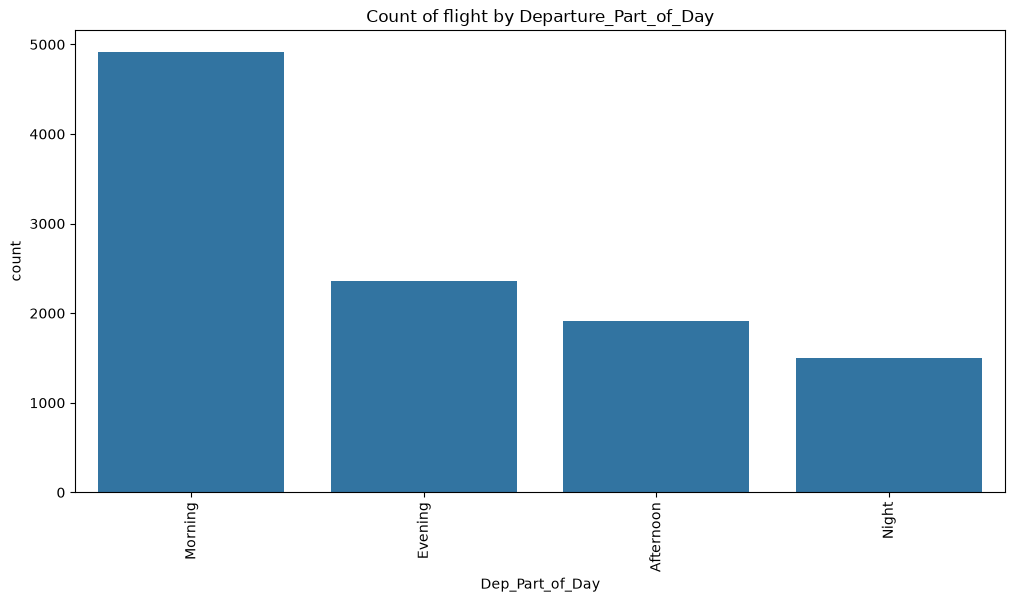

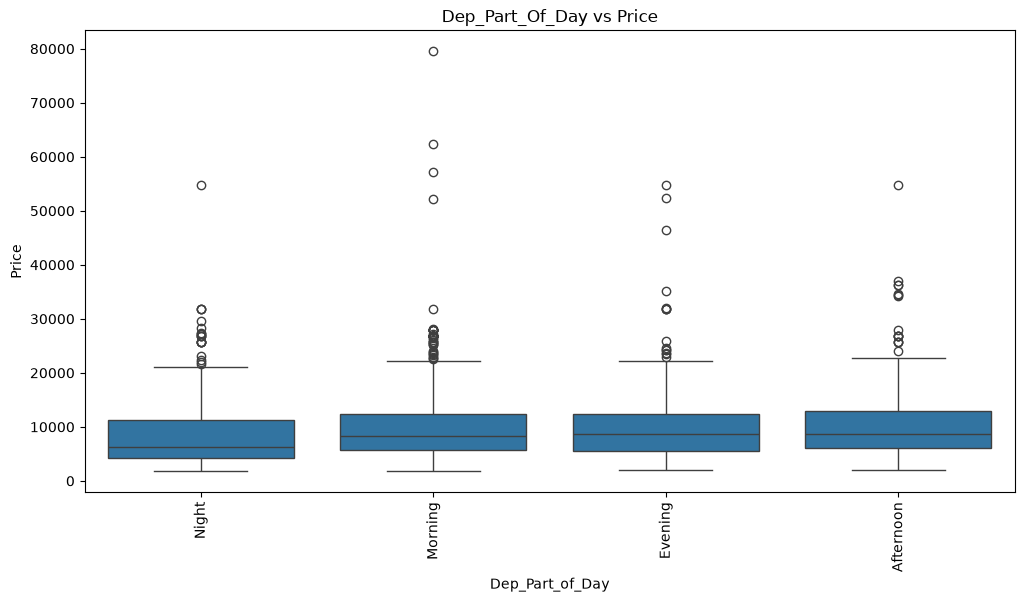

In [32]:
# Dep_Part_of_Day feature distribution
plt.figure(figsize=(12,6))
sns.countplot(data= train_data,x='Dep_Part_of_Day', order= train_data['Dep_Part_of_Day'].value_counts().index)
plt.title('Count of flight by Departure_Part_of_Day')
plt.xticks(rotation=90)
plt.show()

# Dep_Part_of_Day feature dependence on Price
plt.figure(figsize=(12,6))
sns.boxplot(data=train_data, x='Dep_Part_of_Day',y ='Price',
order= train_data.groupby('Dep_Part_of_Day')['Price'].median().sort_values().index)
plt.title('Dep_Part_Of_Day vs Price')
plt.xticks(rotation=90)
plt.show()


# 8. Number Of routes

In [33]:
train_data['Num_Routes'] = train_data['Route'].apply(lambda x: len(x.split('→')))
test_data['Num_Routes'] = test_data['Route'].apply(lambda x: len(x.split('→')))

In [34]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10,6,1,Night,2
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15,2,0,Morning,4
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25,6,1,Morning,4
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30,6,1,Evening,3
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35,4,0,Afternoon,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,150,non-stop,No info,4107,9,4,19,55,22,25,1,0,Evening,2
10679,Air India,Kolkata,Banglore,CCU → BLR,155,non-stop,No info,4145,27,4,20,45,23,20,5,1,Evening,2
10680,Jet Airways,Banglore,Delhi,BLR → DEL,180,non-stop,No info,7229,27,4,8,20,11,20,5,1,Morning,2
10681,Vistara,Banglore,New Delhi,BLR → DEL,160,non-stop,No info,12648,1,3,11,30,14,10,4,0,Morning,2


# 9. Arrival Part of the day

In [35]:
# Arrival part of the day
train_data['Arrival_Part_Of_Day']=train_data['Arrival_Hour'].apply(part_of_day)
test_data['Arrival_Part_Of_Day']=test_data['Arrival_Hour'].apply(part_of_day)


In [36]:
train_data.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour',
       'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute', 'Journey_Day_of_Week',
       'Is_Weekend', 'Dep_Part_of_Day', 'Num_Routes', 'Arrival_Part_Of_Day'],
      dtype='str')

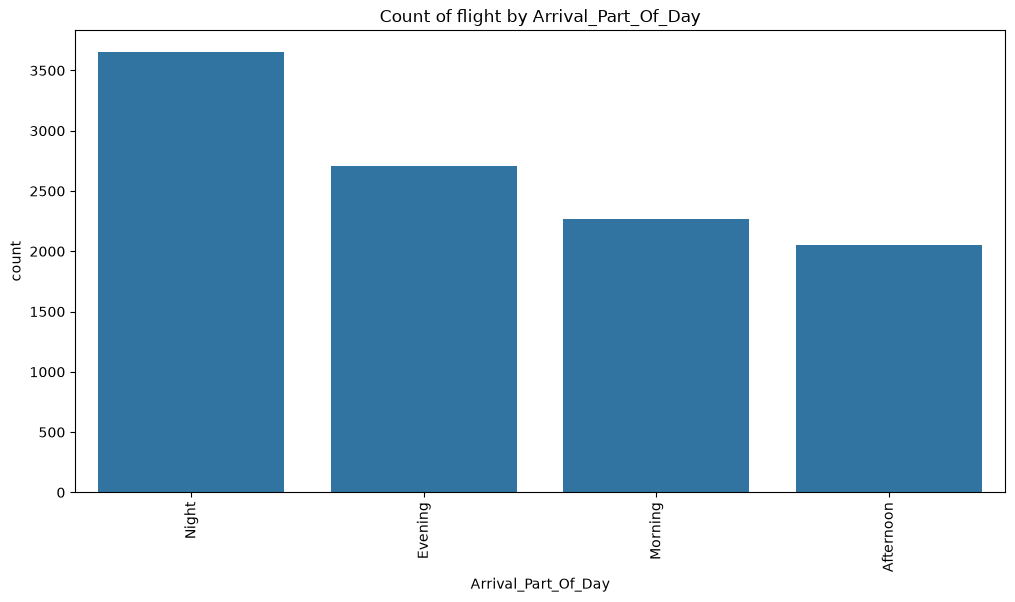

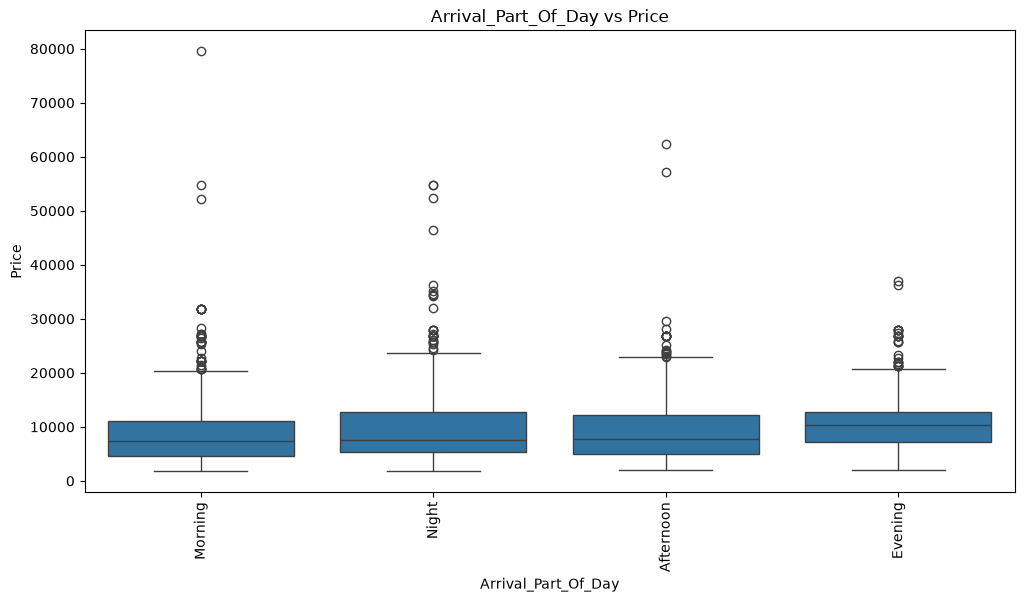

In [45]:
# Arrival_Part_of_Day feature Distribution
plt.figure(figsize=(12,6))
sns.countplot(data= train_data,x='Arrival_Part_Of_Day', order= train_data['Arrival_Part_Of_Day'].value_counts().index)
plt.title('Count of flight by Arrival_Part_Of_Day')
plt.xticks(rotation=90)
plt.show()

#Arrival_Part_of_Day feature dependance on Price
plt.figure(figsize=(12,6))
sns.boxplot(data=train_data, x='Arrival_Part_Of_Day',y ='Price',
order= train_data.groupby('Arrival_Part_Of_Day')['Price'].median().sort_values().index)
plt.title('Arrival_Part_Of_Day vs Price')
plt.xticks(rotation=90)
plt.show()


# 10. Flight Duration in hours

In [38]:
# Flight Duration in hours
train_data['Duration_Hours']=train_data['Duration']/60
test_data['Duration_Hours']= test_data['Duration']/60

In [39]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes,Arrival_Part_Of_Day,Duration_Hours
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10,6,1,Night,2,Night,2.833333
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15,2,0,Morning,4,Afternoon,7.416667
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25,6,1,Morning,4,Night,19.000000
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30,6,1,Evening,3,Night,5.416667
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35,4,0,Afternoon,3,Night,4.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,150,non-stop,No info,4107,9,4,19,55,22,25,1,0,Evening,2,Night,2.500000
10679,Air India,Kolkata,Banglore,CCU → BLR,155,non-stop,No info,4145,27,4,20,45,23,20,5,1,Evening,2,Night,2.583333
10680,Jet Airways,Banglore,Delhi,BLR → DEL,180,non-stop,No info,7229,27,4,8,20,11,20,5,1,Morning,2,Morning,3.000000
10681,Vistara,Banglore,New Delhi,BLR → DEL,160,non-stop,No info,12648,1,3,11,30,14,10,4,0,Morning,2,Afternoon,2.666667


## Dropping Unnecessary features now

In [40]:
train_data.drop(['Route', 'Duration', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute'],axis=1,inplace=True)
test_data.drop(['Route', 'Duration', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute'],axis=1,inplace=True)

In [41]:
train_data

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes,Arrival_Part_Of_Day,Duration_Hours
0,IndiGo,Banglore,New Delhi,non-stop,No info,3897,24,3,6,1,Night,2,Night,2.833333
1,Air India,Kolkata,Banglore,2 stops,No info,7662,1,5,2,0,Morning,4,Afternoon,7.416667
2,Jet Airways,Delhi,Cochin,2 stops,No info,13882,9,6,6,1,Morning,4,Night,19.000000
3,IndiGo,Kolkata,Banglore,1 stop,No info,6218,12,5,6,1,Evening,3,Night,5.416667
4,IndiGo,Banglore,New Delhi,1 stop,No info,13302,1,3,4,0,Afternoon,3,Night,4.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,non-stop,No info,4107,9,4,1,0,Evening,2,Night,2.500000
10679,Air India,Kolkata,Banglore,non-stop,No info,4145,27,4,5,1,Evening,2,Night,2.583333
10680,Jet Airways,Banglore,Delhi,non-stop,No info,7229,27,4,5,1,Morning,2,Morning,3.000000
10681,Vistara,Banglore,New Delhi,non-stop,No info,12648,1,3,4,0,Morning,2,Afternoon,2.666667


In [42]:
train_data.corr(numeric_only=True)

,Price,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Num_Routes,Duration_Hours
Price,1.000000,-0.153774,-0.103643,0.051570,0.020275,0.603897,0.506480
Journey_Day,-0.153774,1.000000,-0.038359,-0.091245,-0.104187,-0.009451,-0.022439
Journey_Month,-0.103643,-0.038359,1.000000,-0.083345,-0.013189,0.054383,0.014836
Journey_Day_of_Week,0.051570,-0.091245,-0.083345,1.000000,0.815513,-0.036750,-0.012729
Is_Weekend,0.020275,-0.104187,-0.013189,0.815513,1.000000,-0.019548,-0.004143
Num_Routes,0.603897,-0.009451,0.054383,-0.036750,-0.019548,1.000000,0.738071
Duration_Hours,0.506480,-0.022439,0.014836,-0.012729,-0.004143,0.738071,1.000000


## 11. Airline

In [43]:
train_data['Airline'].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

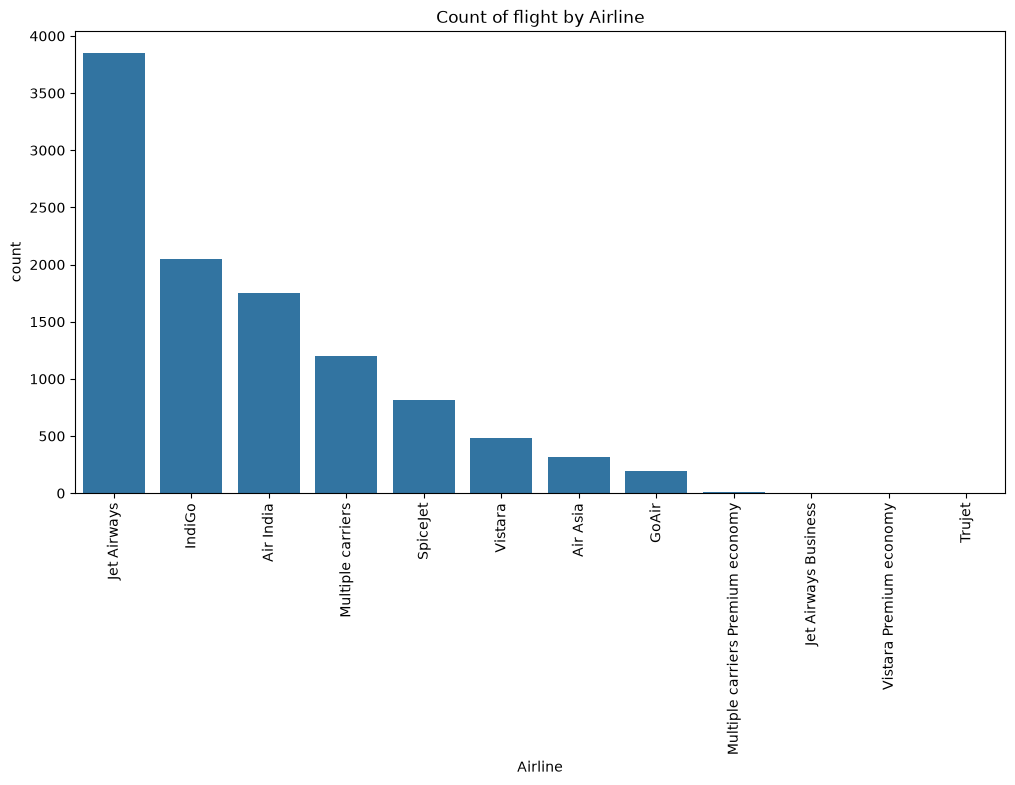

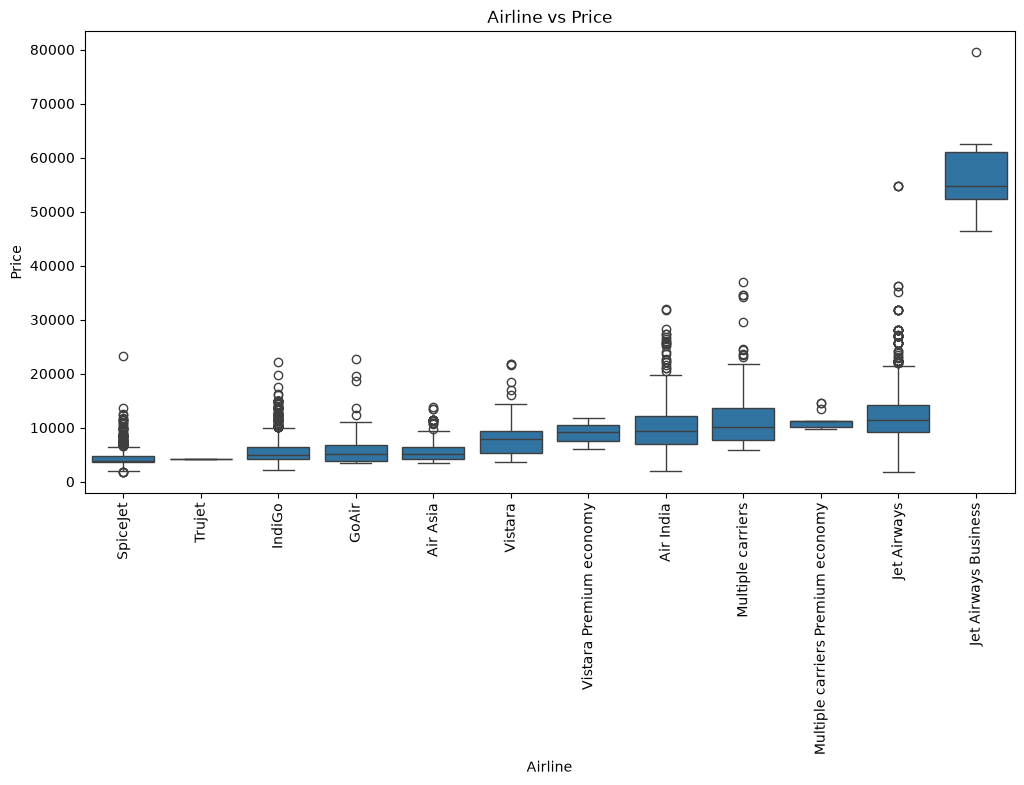

In [44]:
## Airline feature distribution
plt.figure(figsize=(12,6))
sns.countplot(data= train_data,x='Airline', order= train_data['Airline'].value_counts().index)
plt.title('Count of flight by Airline')
plt.xticks(rotation=90)
plt.show()

## Airline feature dependence on Price
plt.figure(figsize=(12,6))
sns.boxplot(data=train_data, x='Airline',y ='Price',
order= train_data.groupby('Airline')['Price'].median().sort_values().index)
plt.title('Airline vs Price')
plt.xticks(rotation=90)
plt.show()
